In [ ]:
!pip install kagglehub --upgrade

In [ ]:
import kagglehub

path = kagglehub.dataset_download("undefinenull/million-song-dataset-spotify-lastfm")

print("Path to dataset files:", path)

100%|██████████| 639M/639M [00:46<00:00, 14.5MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/undefinenull/million-song-dataset-spotify-lastfm/versions/1


In [ ]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data_path = Path("/root/.cache/kagglehub/datasets/undefinenull/million-song-dataset-spotify-lastfm/versions/1")

In [ ]:
songs_data_path = data_path / "Music Info.csv"
users_data_path = data_path / "User Listening  History.csv"

In [ ]:
df_songs = pd.read_csv(songs_data_path)
df_songs.head()

,track_id,name,artist,spotify_preview_url,spotify_id,tags,genre,year,duration_ms,danceability,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,TRIOREW128F424EAF0,Mr. Brightside,The Killers,https://p.scdn.co/mp3-preview/4d26180e6961fd46...,09ZQ5TmUG8TSL56n0knqrj,"rock, alternative, indie, alternative_rock, in...",NaN,2004,222200,0.355,...,1,-4.360,1,0.0746,0.001190,0.000000,0.0971,0.240,148.114,4
1,TRRIVDJ128F429B0E8,Wonderwall,Oasis,https://p.scdn.co/mp3-preview/d012e536916c927b...,06UfBBDISthj1ZJAtX4xjj,"rock, alternative, indie, pop, alternative_roc...",NaN,2006,258613,0.409,...,2,-4.373,1,0.0336,0.000807,0.000000,0.2070,0.651,174.426,4
2,TROUVHL128F426C441,Come as You Are,Nirvana,https://p.scdn.co/mp3-preview/a1c11bb1cb231031...,0keNu0t0tqsWtExGM3nT1D,"rock, alternative, alternative_rock, 90s, grunge",RnB,1991,218920,0.508,...,4,-5.783,0,0.0400,0.000175,0.000459,0.0878,0.543,120.012,4
3,TRUEIND128F93038C4,Take Me Out,Franz Ferdinand,https://p.scdn.co/mp3-preview/399c401370438be4...,0ancVQ9wEcHVd0RrGICTE4,"rock, alternative, indie, alternative_rock, in...",NaN,2004,237026,0.279,...,9,-8.851,1,0.0371,0.000389,0.000655,0.1330,0.490,104.560,4
4,TRLNZBD128F935E4D8,Creep,Radiohead,https://p.scdn.co/mp3-preview/e7eb60e9466bc3a2...,01QoK9DA7VTeTSE3MNzp4I,"rock, alternative, indie, alternative_rock, in...",RnB,2008,238640,0.515,...,7,-9.935,1,0.0369,0.010200,0.000141,0.1290,0.104,91.841,4


In [ ]:
df_songs.shape

(50683, 21)

In [ ]:
df_songs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50683 entries, 0 to 50682
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   track_id             50683 non-null  object 
 1   name                 50683 non-null  object 
 2   artist               50683 non-null  object 
 3   spotify_preview_url  50683 non-null  object 
 4   spotify_id           50683 non-null  object 
 5   tags                 49556 non-null  object 
 6   genre                22348 non-null  object 
 7   year                 50683 non-null  int64  
 8   duration_ms          50683 non-null  int64  
 9   danceability         50683 non-null  float64
 10  energy               50683 non-null  float64
 11  key                  50683 non-null  int64  
 12  loudness             50683 non-null  float64
 13  mode                 50683 non-null  int64  
 14  speechiness          50683 non-null  float64
 15  acousticness         50683 non-null 

In [ ]:
column_drop = ["spotify_preview_url"]

df_songs.drop(columns=column_drop, inplace=True)

df_songs.head()

,track_id,name,artist,spotify_id,tags,genre,year,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,TRIOREW128F424EAF0,Mr. Brightside,The Killers,09ZQ5TmUG8TSL56n0knqrj,"rock, alternative, indie, alternative_rock, in...",NaN,2004,222200,0.355,0.918,1,-4.360,1,0.0746,0.001190,0.000000,0.0971,0.240,148.114,4
1,TRRIVDJ128F429B0E8,Wonderwall,Oasis,06UfBBDISthj1ZJAtX4xjj,"rock, alternative, indie, pop, alternative_roc...",NaN,2006,258613,0.409,0.892,2,-4.373,1,0.0336,0.000807,0.000000,0.2070,0.651,174.426,4
2,TROUVHL128F426C441,Come as You Are,Nirvana,0keNu0t0tqsWtExGM3nT1D,"rock, alternative, alternative_rock, 90s, grunge",RnB,1991,218920,0.508,0.826,4,-5.783,0,0.0400,0.000175,0.000459,0.0878,0.543,120.012,4
3,TRUEIND128F93038C4,Take Me Out,Franz Ferdinand,0ancVQ9wEcHVd0RrGICTE4,"rock, alternative, indie, alternative_rock, in...",NaN,2004,237026,0.279,0.664,9,-8.851,1,0.0371,0.000389,0.000655,0.1330,0.490,104.560,4
4,TRLNZBD128F935E4D8,Creep,Radiohead,01QoK9DA7VTeTSE3MNzp4I,"rock, alternative, indie, alternative_rock, in...",RnB,2008,238640,0.515,0.430,7,-9.935,1,0.0369,0.010200,0.000141,0.1290,0.104,91.841,4


In [ ]:
# check missing values

df_songs.isna().sum()

,0
track_id,0
name,0
artist,0
spotify_id,0
tags,1127
genre,28335
year,0
duration_ms,0
danceability,0
energy,0


In [ ]:
!pip install missingno

import missingno as msno

<Axes: >

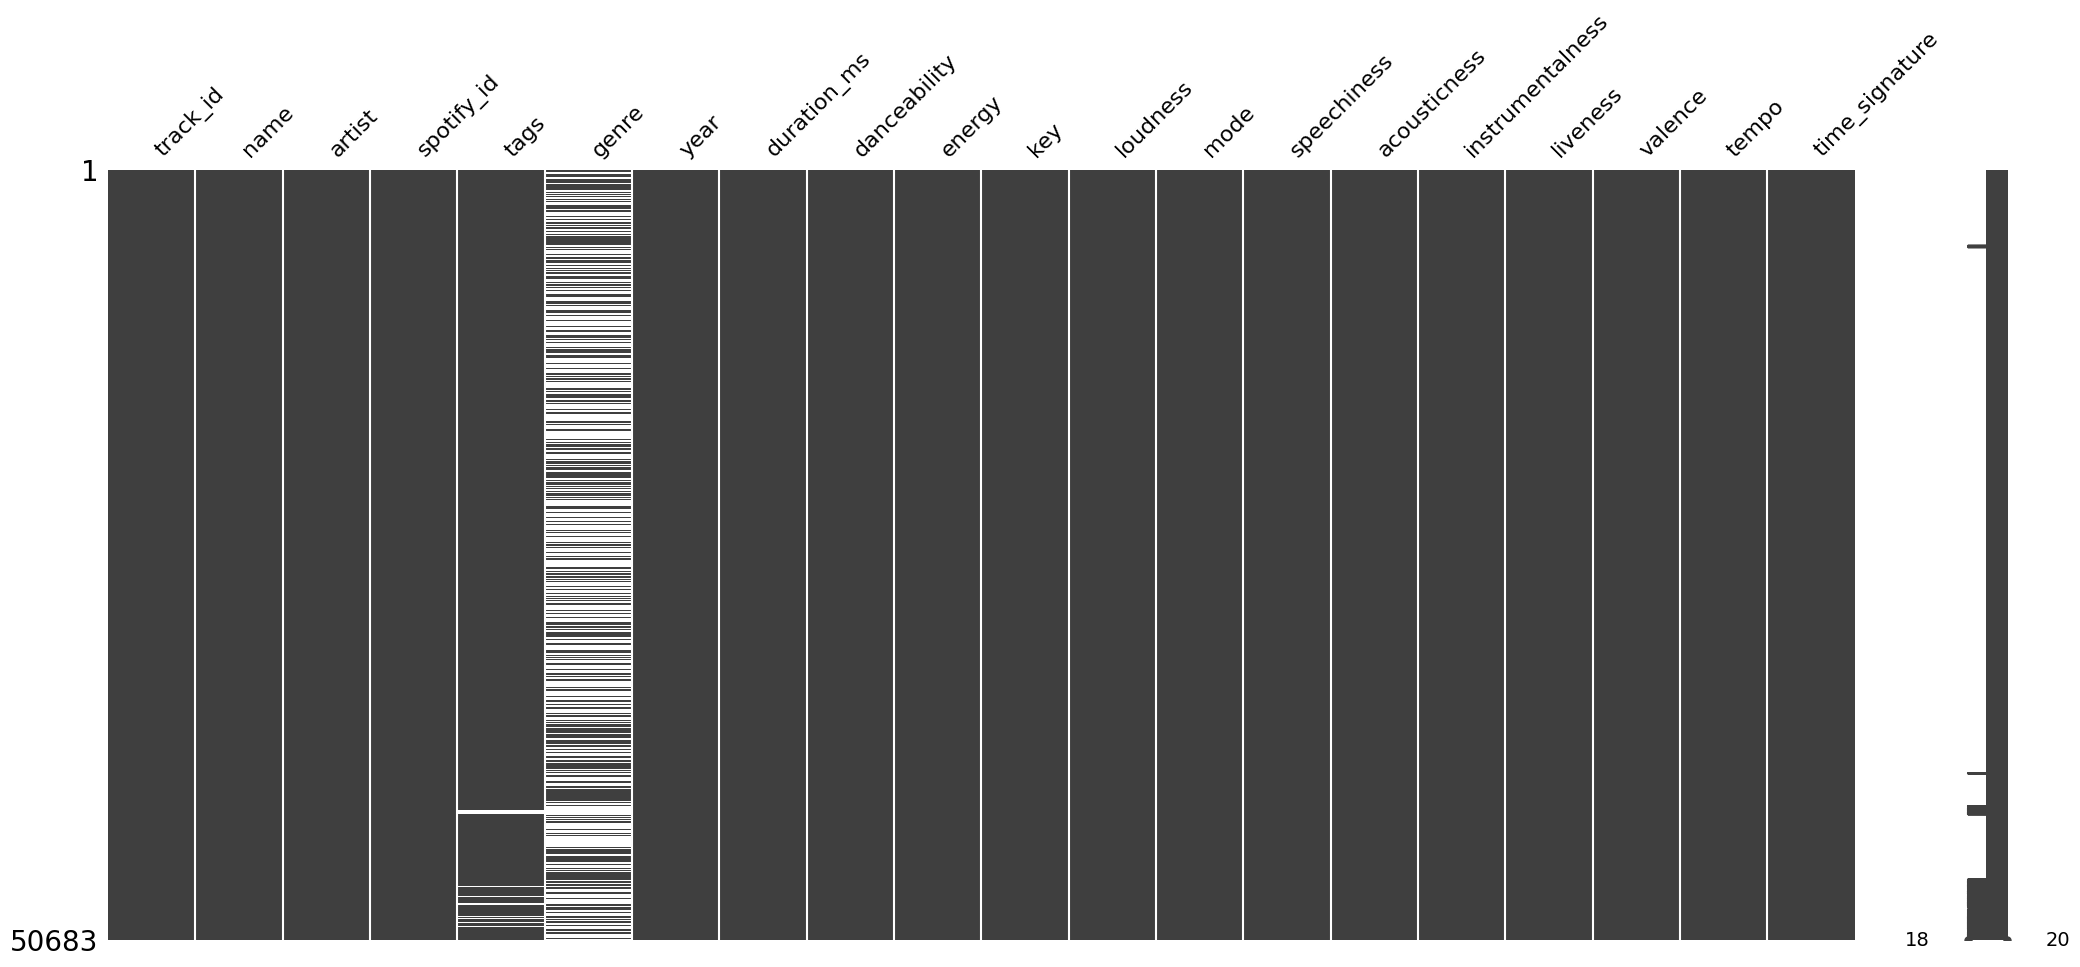

In [ ]:
msno.matrix(df_songs)

In [ ]:
# ratio of missing values in data

(df_songs.isna().mean().sort_values(ascending=False).head(2).mul(100))

,0
genre,55.906320
tags,2.223625


In [ ]:
# duplicates in data based on names of song

int(df_songs.assign(name=df_songs['name'].str.lower())
 .duplicated(subset='name')
 .sum())

815

In [ ]:
# rows that are duplicate

(
    df_songs
    .loc[
        df_songs
        .assign(name=df_songs['name'].str.lower())
        .duplicated(subset='name',keep=False)
    ]
    .assign(name=df_songs['name'].str.lower())
    .sort_values("name")
)

,track_id,name,artist,spotify_id,tags,genre,year,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
34480,TRKKZMK128F4257579,3 am,Liv Kristine,1TgsnkiolcBhQssCR37JXx,"female_vocalists, power_metal, gothic_metal, g...",NaN,2005,302880,0.516,0.840,0,-6.038,0,0.0390,0.152000,0.005970,0.107,0.441,78.009,4
6588,TRGGALK12903CB68E5,3 am,Matchbox Twenty,5vYA1mW9g2Coh1HUFUSmlb,"rock, alternative, pop, alternative_rock, 90s,...",NaN,1996,225946,0.521,0.673,8,-8.685,1,0.0284,0.005730,0.000000,0.120,0.543,108.031,4
29795,TRLOXMF128F934BF04,3am,Matchbox Twenty,5vYA1mW9g2Coh1HUFUSmlb,"rock, alternative, 90s, piano, american, pop_rock",NaN,1996,225946,0.521,0.673,8,-8.685,1,0.0284,0.005730,0.000000,0.120,0.543,108.031,4
43800,TRPWOAS128E0781045,3am,Halsey,1OfLNb6dQ9dra1B58iT9Ex,pop_rock,NaN,2020,234858,0.385,0.871,0,-4.604,0,0.0795,0.009060,0.000000,0.579,0.538,189.760,4
15088,TRJRBRX128F4255789,4th of july,Soundgarden,237oH9rNUYpIBeHfAn3WJ0,"hard_rock, 90s, grunge",NaN,1994,308866,0.368,0.749,5,-5.523,0,0.0392,0.109000,0.000372,0.175,0.193,141.901,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34772,TRJFGYO128F4259743,you're the one that i want,Lo-Fang,1dEHQktvcM8vCCyI1x7yVB,"indie, male_vocalists, cover",NaN,2014,204706,0.445,0.309,11,-12.517,0,0.0404,0.643000,0.000369,0.224,0.153,119.754,4
32677,TRFZYLL128F146902A,you've really got a hold on me,Smokey Robinson and The Miracles,03AkIZeRvGpTvDF9vNJtdj,"soul, 60s, oldies",Rock,2012,179513,0.674,0.515,0,-6.895,1,0.0296,0.724000,0.000000,0.339,0.596,116.678,3
20976,TRUXHGS128F145E41A,you've really got a hold on me,The Miracles,01FtGX94CSvO5Zxs5B6AMM,"soul, 60s, oldies",NaN,1994,180266,0.679,0.406,0,-10.533,1,0.0312,0.755000,0.000000,0.412,0.511,117.940,3
27680,TRXWPMW12903CB42A0,zombies,Childish Gambino,73kAUSAht4YOR7xNPmNb2L,funk,NaN,2016,281813,0.653,0.411,0,-11.986,1,0.1270,0.503000,0.000969,0.067,0.468,160.055,4


In [ ]:
# drop duplicates

df_songs.drop_duplicates(subset=["spotify_id","year","duration_ms"],inplace=True)

In [ ]:
# check for duplicates

(
    df_songs
    .duplicated(subset=["spotify_id","year","duration_ms"])
    .sum()
)

np.int64(0)

# ***Column Wise Analysis***

In [ ]:
# list of columns in data

df_songs.columns

Index(['track_id', 'name', 'artist', 'spotify_id', 'tags', 'genre', 'year',
       'duration_ms', 'danceability', 'energy', 'key', 'loudness', 'mode',
       'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'time_signature'],
      dtype='object')

In [ ]:
df_songs.dtypes

,0
track_id,object
name,object
artist,object
spotify_id,object
tags,object
genre,object
year,int64
duration_ms,int64
danceability,float64
energy,float64


In [ ]:
df_songs.shape

(50674, 20)

In [ ]:
# Categorical Columns

categorical_features = df_songs.select_dtypes(include="object").columns
categorical_features

Index(['track_id', 'name', 'artist', 'spotify_id', 'tags', 'genre'], dtype='object')

In [ ]:
def categorical_analysis(df,feature_names,k_artists=15):
    for feature in feature_names:
        print(f"Number of categories in column {feature} are ",df[feature].str.lower().nunique())

        if feature in ["artist","genre"]:
            print(df[feature].value_counts().head(k_artists))

        if feature == "genre":
            print(f"The unique categories in {feature} column are: ", df[feature].dropna().unique())
        print("#" * 75)

In [ ]:
# perform catagorical analysis

categorical_analysis(df_songs,categorical_features)

Number of categories in column track_id are  50674
###########################################################################
Number of categories in column name are  49860
###########################################################################
Number of categories in column artist are  8317
artist
The Rolling Stones    132
Radiohead             110
Autechre              105
Tom Waits             100
Bob Dylan              98
The Cure               94
Metallica              85
Johnny Cash            84
Nine Inch Nails        83
Sonic Youth            81
Iron Maiden            76
In Flames              76
Elliott Smith          76
Mogwai                 75
Boards of Canada       75
Name: count, dtype: int64
###########################################################################
Number of categories in column spotify_id are  50674
###########################################################################
Number of categories in column tags are  20054
###########################

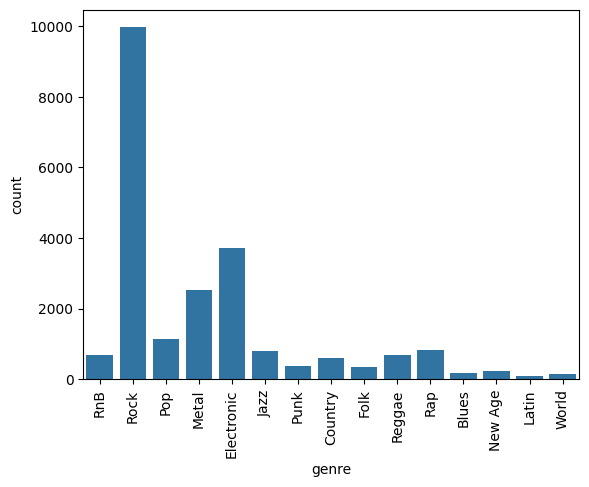

In [ ]:
# countplot of genre

sns.countplot(df_songs,x="genre")
plt.xticks(rotation=90)
plt.show()

In [ ]:
# genre group

genre_group = df_songs.groupby("genre")

genre_group[['genre','tags']].sample(3)

,genre,tags
36234,Blues,"soul, oldies"
15459,Blues,"classic_rock, instrumental, blues, psychedelic..."
32359,Blues,indie_pop
33171,Country,country
27541,Country,"jazz, german"
33364,Country,country
21856,Electronic,"ambient, experimental, instrumental, classical..."
31066,Electronic,"electronic, trip_hop, french"
44947,Electronic,drum_and_bass
36857,Folk,"indie, folk, acoustic, french"


In [ ]:
# song titles in the data that are not in english

(df_songs
    .loc[
        df_songs
        .loc[:,"name"]
        .str.contains("[^\d\w\s.?!':;-_(){},\.#-&/-]")
    ]
)

<>:7: SyntaxWarning: invalid escape sequence '\d'
<>:7: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_2022/1189661129.py:7: SyntaxWarning: invalid escape sequence '\d'
  .str.contains("[^\d\w\s.?!':;-_(){},\.#-&/-]")


,track_id,name,artist,spotify_id,tags,genre,year,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
2455,TRBGIZH128F4252D9E,2 + 2 = 5,Radiohead,0dUSgj5UiJHY92RCuEFYcx,"rock, electronic, alternative, indie, alternat...",Rock,2008,199360,0.443,0.717,5,-5.498,0,0.0504,0.182000,0.000051,0.3450,0.3860,149.582,4
4463,TRGHMRU128F1478067,"I Put The ""Metro"" In Metronome",Cute Is What We Aim For,718VxOgHaLU7oGS9686hg6,"alternative, emo",Rock,2006,206053,0.538,0.858,11,-3.862,1,0.0638,0.085200,0.000000,0.2580,0.7060,149.971,4
6870,TRGIILN12903CE46BB,1+1,Beyoncé,0b4bcwV5QWTzgza5u1gh5C,"female_vocalists, soul, rnb, beautiful",NaN,2011,273880,0.303,0.384,6,-7.342,1,0.0339,0.381000,0.000005,0.0661,0.2610,63.345,5
7902,TRZMLSV128F9305C8C,B********,Rammstein,2fKyVXrtvFkqv5lVPf1UXa,"metal, industrial, german",Rock,2009,254013,0.352,0.905,9,-3.792,1,0.0836,0.000895,0.218000,0.1810,0.3270,141.016,3
7974,TRFRAEO128F4279C87,F**k the System,System of a Down,0uvPnGOwcaUNT6gwJF98wL,"metal, nu_metal",Metal,2002,132733,0.474,0.994,8,-1.884,1,0.1030,0.002160,0.126000,0.3140,0.8470,171.433,4
10722,TRODWHD128F92FD8BA,4 + 20,"Crosby, Stills, Nash & Young",2jZPEeW2ynykb2GkVqpOkJ,"rock, classic_rock, folk, singer_songwriter, a...",Rock,1970,126640,0.638,0.058,4,-25.243,1,0.0388,0.928000,0.079000,0.1130,0.1260,140.964,4
13127,TRLMIXB128EF3435DD,M+M's,blink-182,0z6VQdAqi0HjQYULMUYpBt,"punk, punk_rock",NaN,2005,155680,0.212,0.921,9,-6.092,1,0.0567,0.000054,0.003990,0.0669,0.6800,159.629,4
14454,TRKEIVB128F930A597,"Nuthin' But a ""G"" Thang",Dr. Dre,1qaZx6y94LiMy2KdhHxRTy,"rap, 90s, hip_hop",NaN,2005,230026,0.817,0.704,7,-8.336,1,0.2850,0.009390,0.000000,0.0850,0.6800,94.627,4
17862,TRBZLOG12903CB78FD,I Belong To You [+Mon Coeur S'Ouvre A Ta Voix],Muse,114rzL6VEy9bb3amPcY3tw,"rock, alternative_rock, progressive_rock, soun...",Rock,2009,338813,0.481,0.603,2,-6.590,1,0.0280,0.166000,0.032100,0.1090,0.2130,105.974,4
22541,TRYVOPZ128F4254176,£4,These New Puritans,1LsQ5WkLU8ubiAz6AtMNll,"electronic, alternative, british, industrial, ...",Rock,2008,133173,0.692,0.759,11,-9.216,1,0.0533,0.052200,0.012900,0.4630,0.2560,99.988,4


In [ ]:
# artists in the data that are not in english

(df_songs
    .loc[
        df_songs
        .loc[:,"artist"]
        .str.contains("[^\d\w\s.?!':;-_\(\)\{\},\.#-+&\/\-\"]")
    ]
)

<>:7: SyntaxWarning: invalid escape sequence '\d'
<>:7: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_2022/2814537950.py:7: SyntaxWarning: invalid escape sequence '\d'
  .str.contains("[^\d\w\s.?!':;-_\(\)\{\},\.#-+&\/\-\"]")


,track_id,name,artist,spotify_id,tags,genre,year,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
25657,TRUOKRP128F9306B97,DAYBREAK'S BELL,L'Arc~en~Ciel,0f6N93Iqa1jIGY87ckKe8h,"japanese, j_pop",NaN,2007,251653,0.442,0.939,7,-4.032,1,0.0432,0.001010,0.000282,0.3040,0.780,156.138,4
25688,TRYYZGB128F9306B92,MY HEART DRAWS A DREAM,L'Arc~en~Ciel,0K1VcVuws8cBEOS8bb8Svo,"japanese, j_pop",NaN,2007,256826,0.449,0.812,2,-4.105,1,0.0332,0.000732,0.000000,0.1130,0.287,131.850,4
25696,TRYAFFS128F425E71A,Seventh Heaven,L'Arc~en~Ciel,0vc0kp9kYeqLCoDOKFYESL,"japanese, j_pop",NaN,2007,301373,0.488,0.963,9,-3.486,1,0.0532,0.000381,0.000000,0.7340,0.795,129.963,4
25704,TRZBUIY128F9306B9D,Hurry Xmas,L'Arc~en~Ciel,0NMWlIwjGldOgbABHTYx82,"japanese, j_pop",Rock,2007,289133,0.447,0.869,0,-3.362,1,0.0508,0.043600,0.000001,0.1350,0.562,116.043,4
25715,TRDLCHM128F427F235,Spirit dreams inside,L'Arc~en~Ciel,0hyTPlLk6MWOGiKFstN0S2,japanese,NaN,2002,224013,0.510,0.959,9,-4.793,1,0.0548,0.000194,0.002000,0.1950,0.693,118.017,4
25763,TRKTCEP128F9306B91,Pretty girl,L'Arc~en~Ciel,0QUESFm42vSLGffjwud4jl,"japanese, j_pop",Rock,2007,197866,0.373,0.954,0,-3.024,1,0.0777,0.001360,0.000000,0.0548,0.695,176.037,4
25788,TRMDISG128EF341CBC,Lover Boy,L'Arc~en~Ciel,69Gd7FRSCuB4X7D7gDOdhz,japanese,NaN,2004,285026,0.428,0.977,4,-4.600,0,0.0701,0.003850,0.001320,0.1630,0.504,152.023,4
25790,TRHNIIF128F42884A7,TRUST,L'Arc~en~Ciel,5ROfpAhDOiDkyn17SNDtAG,japanese,NaN,2005,269066,0.507,0.895,2,-5.892,1,0.0432,0.002160,0.002600,0.0745,0.393,95.965,4
25799,TRMZMPL128F1490F27,Niji,L'Arc~en~Ciel,1AhmwzPwhatp999J4Ky9nH,"japanese, j_pop",NaN,1998,305600,0.521,0.706,2,-6.931,1,0.0284,0.001310,0.000206,0.3610,0.534,93.020,4
25800,TRANWBU128F42717D4,My Dear,L'Arc~en~Ciel,12UBEdmkCBXtnbnQEvdHWp,japanese,NaN,2005,309826,0.464,0.804,8,-5.762,0,0.0320,0.198000,0.006470,0.1360,0.362,112.013,4


In [ ]:
df_songs['tags'][0]

'rock, alternative, indie, alternative_rock, indie_rock, 00s'

In [ ]:
all_tags = []

for tags in df_songs["tags"].dropna().str.replace(" ","").str.split(","):
    all_tags.extend(tags)

In [ ]:
print("The number of unique tags are ",len(set(all_tags)))

The number of unique tags are  100


In [ ]:
set(all_tags)

{'00s',
 '60s',
 '70s',
 '80s',
 '90s',
 'acoustic',
 'alternative',
 'alternative_rock',
 'ambient',
 'american',
 'avant_garde',
 'beautiful',
 'black_metal',
 'blues',
 'blues_rock',
 'british',
 'britpop',
 'chill',
 'chillout',
 'classic_rock',
 'classical',
 'country',
 'cover',
 'dance',
 'dark_ambient',
 'death_metal',
 'doom_metal',
 'downtempo',
 'drum_and_bass',
 'electro',
 'electronic',
 'emo',
 'experimental',
 'female_vocalists',
 'folk',
 'french',
 'funk',
 'german',
 'gothic',
 'gothic_metal',
 'grindcore',
 'grunge',
 'guitar',
 'hard_rock',
 'hardcore',
 'heavy_metal',
 'hip_hop',
 'house',
 'idm',
 'indie',
 'indie_pop',
 'indie_rock',
 'industrial',
 'instrumental',
 'j_pop',
 'japanese',
 'jazz',
 'lounge',
 'love',
 'male_vocalists',
 'mellow',
 'melodic_death_metal',
 'metal',
 'metalcore',
 'new_age',
 'new_wave',
 'noise',
 'nu_metal',
 'oldies',
 'piano',
 'polish',
 'pop',
 'pop_rock',
 'post_hardcore',
 'post_punk',
 'post_rock',
 'power_metal',
 'progress

In [ ]:
# unique tags in the data

(df_songs
    .loc[:,"tags"]
    .dropna()
    .str.split(",")
    .explode()
    .str.strip()
    .unique()
)

array(['rock', 'alternative', 'indie', 'alternative_rock', 'indie_rock',
       '00s', 'pop', 'british', '90s', 'love', 'britpop', 'grunge',
       'piano', 'beautiful', 'mellow', 'chillout', 'funk', 'electronic',
       'dance', 'hip_hop', 'trip_hop', 'metal', 'hard_rock', 'nu_metal',
       'progressive_rock', 'classic_rock', '80s', '70s', 'experimental',
       'soundtrack', 'female_vocalists', 'heavy_metal', 'rap', '60s',
       'post_punk', 'pop_rock', 'punk', 'punk_rock', 'acoustic', 'emo',
       'new_wave', 'chill', 'indie_pop', 'gothic_metal', 'gothic',
       'thrash_metal', 'folk', 'singer_songwriter', 'country', 'cover',
       'blues_rock', 'psychedelic', 'psychedelic_rock', 'guitar',
       'american', 'ska', 'ambient', 'blues', 'oldies', 'french',
       'male_vocalists', 'reggae', 'instrumental', 'jazz', 'avant_garde',
       'industrial', 'german', 'synthpop', 'hardcore', 'metalcore',
       'screamo', 'post_rock', 'swedish', 'doom_metal', 'power_metal',
       'rnb', 

In [ ]:
integer_columns = df_songs.select_dtypes(include="int").columns
integer_columns

Index(['year', 'duration_ms', 'key', 'mode', 'time_signature'], dtype='object')

In [ ]:
df_songs[integer_columns]

,year,duration_ms,key,mode,time_signature
0,2004,222200,1,1,4
1,2006,258613,2,1,4
2,1991,218920,4,0,4
3,2004,237026,9,1,4
4,2008,238640,7,1,4
...,...,...,...,...,...
50678,2008,273440,6,0,4
50679,2004,275133,0,1,4
50680,2014,254826,10,0,4
50681,2008,243293,4,0,4


In [ ]:
# statistical summary

(df_songs
    .loc[:,integer_columns]
    .drop(columns=["duration_ms"])
    .assign(**{
        col: df_songs[col].astype("object")
        for col in integer_columns.drop("duration_ms")
    })
    .describe()
)

,year,key,mode,time_signature
count,50674,50674,50674,50674
unique,75,12,2,5
top,2007,9,1,4
freq,4221,5907,31979,44981


In [ ]:
# range of data

(df_songs
    .loc[:,integer_columns]
    .assign(duration_minutes=df_songs["duration_ms"].div(1000).div(60))
    .drop(columns=["duration_ms"])
    .agg(["min","max"])
)

,year,key,mode,time_signature,duration_minutes
min,1900,0,0,0,0.023983
max,2022,11,1,5,63.606217


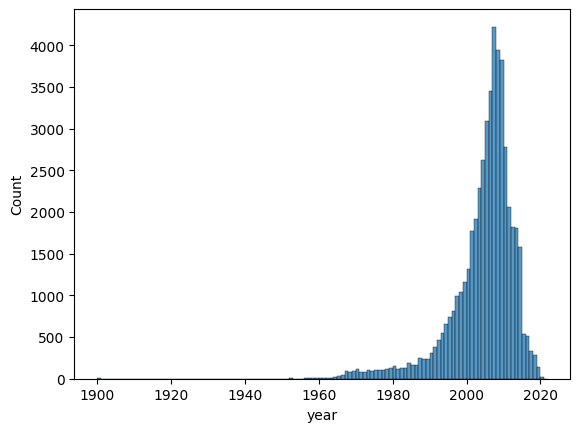

In [ ]:
# number of songs per year in data

sns.histplot(df_songs,x="year",bins=df_songs["year"].max() - df_songs["year"].min(),stat="count")
plt.show()